In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path

import polars as pl

from sailpack.export_load_case_mapping_seed import (
    build_records as build_mapping_records,
)
from sailpack.export_reference_values_seed import (
    build_reference_records,
)
from sailpack.parse import parse_directory
from sailpack.seed_utils import (
    build_load_case_records,
    extract_load_cases,
    read_reference_values_mapping,
)

sailpack_dir = Path("../sailpack")
load_cases_dir = sailpack_dir / "load_cases"
result = parse_directory(load_cases_dir)

# Show conditions

calculation_id,tws,twa,aws,awa,bsp,heel,sail_set
str,f64,f64,f64,f64,f64,f64,str
"""LC7-R_ SS_M2R_MZ2R_TWA90_TWS28…",28.0,-69.3,37.83,42.5,18.0,20.0,"""M2R+MZ2R+SS"""
"""LC7_ SS_M2R_MZ2R_TWA45_TWS26_R…",27.0,-39.9,36.83,25.8,12.5,20.0,"""M2R+MZ2R+SS"""
"""LC53_FM_FMZ_TWA120_TWS20_RM20_…",20.0,-86.0,24.19,55.2,12.4,20.0,"""FM+FMZ"""
"""LC10_ SJ_TWA60_TWS45_RM10_2024…",45.0,-47.7,53.36,36.8,12.5,10.0,"""SJ"""
"""LC33_ A3_FM_FMZ_ TWA125_TWS15_…",15.0,-91.6,22.3,40.8,17.3,20.0,"""A3+FM+FMZ"""
…,…,…,…,…,…,…,…
"""LC66_TSOnly_TWS45_TWA45""",45.0,-45.0,51.88,36.4,10.0,13.0,""""""
"""LC8_ SS_M2R_TWA50_TWS27_RM15_2…",27.0,-43.1,36.97,27.9,13.0,15.0,"""M2R+SS"""
"""LC2_ B_FM_MZ1R_TWA45_TWS16_RM2…",16.0,-42.5,26.43,21.7,12.8,22.0,"""B+FM+MZ1R"""


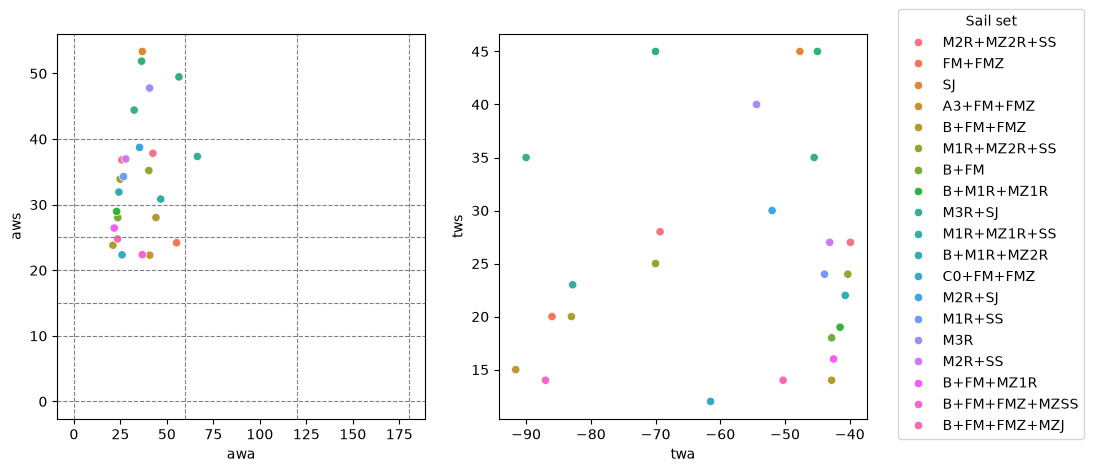

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

from sailpack.export_load_case_mapping_seed import AWA_RANGES, AWS_RANGES
from sailpack.seed_utils import extract_sail_abbreviations


def add_sail_set_column(
    df: pl.DataFrame, id_col: str = "calculation_id", new_col: str = "sail_set"
) -> pl.DataFrame:
    return df.with_columns(
        pl.col(id_col)
        .map_elements(
            lambda calc_id: "+".join(sorted(extract_sail_abbreviations(calc_id))),
            return_dtype=pl.String,
        )
        .alias(new_col)
    )


conditions = add_sail_set_column(extract_load_cases(result))
df = conditions.to_pandas(use_pyarrow_extension_array=True)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="awa", y="aws", hue="sail_set", ax=ax, legend=True)
sns.scatterplot(data=df, x="twa", y="tws", hue="sail_set", ax=ax2, legend=False)

# reference lines for the upwind/reaching/downwind and speed bands used when seeding load case mappings
awa_boundaries = sorted({bound for r in AWA_RANGES.values() for bound in r})
aws_boundaries = sorted({bound for r in AWS_RANGES for bound in r if bound is not None})
for x in awa_boundaries:
    ax.axvline(x, color="gray", linestyle="--", linewidth=0.8)
for y in aws_boundaries:
    ax.axhline(y, color="gray", linestyle="--", linewidth=0.8)

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.subplots_adjust(right=0.8)
fig.legend(
    handles, labels, title="Sail set", loc="center left", bbox_to_anchor=(0.82, 0.5)
)

conditions

## Map to Loads app

In [17]:
mapping = read_reference_values_mapping(sailpack_dir / "sailpack_mapping.csv")
mapping

Variable key,Technical name,name in LC sheet by Stevo,Sailpack table name,Sailpack row label,Sailpack column label,Note on getting var from Sailpack
str,str,str,str,str,str,str
"""aft-winch-load-ps""","""aft-winch-load-ps""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_PORT""","""Load (N)""","""May also carry loads from oth…"
"""aft-winch-load-sb""","""aft-winch-load-sb""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_PORT""","""Load (N)""","""May also carry loads from oth…"
"""aft-winch-load""","""aft-winch-load-sb""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_STBD""","""Load (N)""","""May also carry loads from othe…"
"""aft-winch-load""","""aft-winch-load-ps""","""Mizzen jib sheet load""","""CABLE DATA""","""CABLE_MIZZEN_JIB_SHEET""","""Load (N)""",null
"""blade-adjuster-load""","""blade-adjuster-load""","""Main head stay""","""CABLE DATA""","""CABLE__FS""","""Load (N)""",null
…,…,…,…,…,…,…
"""mizzen-outhaul-relative-positi…","""mizzen-outhaul-relative-positi…","""Mizzen outhaul / REEF""","""CABLE DATA""","""CABLE_MIZZENCLEW""","""Trimming value (N or m)""",null
"""mizzen-preventer-load""","""mizzen-preventer-load""","""Mizzen Preventer sheet""","""CABLE DATA""","""CABLE_MIZZEN_PREVENTER""","""Load (N)""",null
"""mizzen-runner-load""","""mizzen-runner-load-ps""","""Mizzen runner (remap?)""","""CABLE DATA""","""CABLE_MIZZ_RUNNER""","""Load (N)""","""2 x Mizzen Runner Tail Load Pi…"


In [18]:
load_case_records = build_load_case_records(result)
reference_records = build_reference_records(result, mapping)
mapping_records = build_mapping_records(load_cases_dir)


load_cases = pl.DataFrame(load_case_records)
reference_values = pl.DataFrame(reference_records)
load_case_mapping = pl.DataFrame(mapping_records)

load_cases, reference_values, load_case_mapping

(shape: (23, 9)
 ┌───────────────────┬───────────────────┬──────┬───────┬───┬──────┬──────┬──────┬──────────────────┐
 │ id                ┆ name              ┆ tws  ┆ twa   ┆ … ┆ awa  ┆ bsp  ┆ heel ┆ sail_abbreviatio │
 │ ---               ┆ ---               ┆ ---  ┆ ---   ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ns               │
 │ str               ┆ str               ┆ f64  ┆ f64   ┆   ┆ f64  ┆ f64  ┆ f64  ┆ ---              │
 │                   ┆                   ┆      ┆       ┆   ┆      ┆      ┆      ┆ list[str]        │
 ╞═══════════════════╪═══════════════════╪══════╪═══════╪═══╪══════╪══════╪══════╪══════════════════╡
 │ LC8_ SS_M2R_TWA50 ┆ LC8_ SS_M2R_TWA50 ┆ 27.0 ┆ -43.1 ┆ … ┆ 27.9 ┆ 13.0 ┆ 15.0 ┆ ["M2R", "SS"]    │
 │ _TWS27_RM15_2…    ┆ _TWS27_RM15_2…    ┆      ┆       ┆   ┆      ┆      ┆      ┆                  │
 │ LC22_             ┆ LC22_             ┆ 14.0 ┆ -50.3 ┆ … ┆ 23.5 ┆ 13.8 ┆ 22.0 ┆ ["B", "FM", …    │
 │ B_FM_FMZ_MZJ_     ┆ B_FM_FMZ_MZJ_     ┆      ┆       ┆   ┆     

In [19]:
reference_values

load_case_id,variable_key,target,alarm_low,warning_low,warning_high,alarm_high
str,str,f64,null,null,null,null
"""LC65-2_M3R_TWA70_TWS40_RM12_20…","""fiber-optic-mizzen-v1-sb""",25.660343,null,null,null,null
"""LC9_ SJ_M3R_TWA55_TWS35_RM12_2…","""fiber-optic-mizzen-v1-sb""",25.659629,null,null,null,null
"""LC7-R_ SS_M2R_MZ2R_TWA90_TWS28…","""fiber-optic-mizzen-v1-sb""",14.021302,null,null,null,null
"""LC20_ MH0_FM_FMZ_ TWA70_TWS12_…","""fiber-optic-mizzen-v1-sb""",13.785238,null,null,null,null
"""LC66_TSOnly_TWS45_TWA70""","""fiber-optic-mizzen-v1-sb""",27.533459,null,null,null,null
…,…,…,…,…,…,…
"""LC53_FM_FMZ_TWA120_TWS20_RM20_…","""mizzen-runner-combined-load""",2.711221,null,null,null,null
"""LC___FM_B_TWA45_TWS18_RM22_202…","""mizzen-runner-combined-load""",7.922787,null,null,null,null
"""LC22_ B_FM_FMZ_MZJ_ TWA55_TWS1…","""mizzen-runner-combined-load""",8.254705,null,null,null,null
